This notebook is the code for training a GAN for generating synthetic dataset, it was based on the Goodfellow et al. 2014 paper.
GAN consist of a generator and discriminator, which are in a form adversarial competition to produce data that is similr to the input real data.

In [ ]:
#import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# Import original data split
# Data split using random shuffle split based on 70-30 split (in another notebook)

df1= pd.read_csv('/content/Split_train_data.csv')
Split_train_data= df1[['Depth', 'Res', 'Su_kpa']]
Split_train_data

,Depth,Res,Su_kpa
0,3.27,32.1000,135.418914
1,12.90,49.5290,306.740091
2,11.00,51.0000,1318.124378
3,11.00,95.7000,725.022034
4,11.00,50.1000,1904.470862
...,...,...,...
296,11.00,55.8705,218.793631
297,0.00,19.8030,146.934939
298,7.49,23.4000,1121.715866
299,4.56,17.7589,208.163554


Scaling data

In [ ]:
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
#Load and normalize data usign standard scaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(Split_train_data.values)

data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
batch_size = 64
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

SET UP GAN

In [ ]:

#  Generator & Discriminator
class Generator(nn.Module):
    def __init__(self, latent_dim=10):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 3),
            nn.Sigmoid()
        )
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(3, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.model(x)


In [ ]:
#Initialize networks
latent_dim = 10
G = Generator(latent_dim)
D = Discriminator()

#Weight initialization
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

G.apply(weights_init)
D.apply(weights_init)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G = G.to(device)
D = D.to(device)

Epoch [1/4000] | D Loss: 1.3862 | G Loss: 0.6935
Epoch [100/4000] | D Loss: 1.3767 | G Loss: 0.7763
Epoch [200/4000] | D Loss: 1.3754 | G Loss: 0.7775
Epoch [300/4000] | D Loss: 1.3748 | G Loss: 0.7804
Epoch [400/4000] | D Loss: 1.3753 | G Loss: 0.7792
Epoch [500/4000] | D Loss: 1.3757 | G Loss: 0.7757
Epoch [600/4000] | D Loss: 1.3768 | G Loss: 0.7776
Epoch [700/4000] | D Loss: 1.3756 | G Loss: 0.7796
Epoch [800/4000] | D Loss: 1.3762 | G Loss: 0.7795
Epoch [900/4000] | D Loss: 1.3763 | G Loss: 0.7787
Epoch [1000/4000] | D Loss: 1.3754 | G Loss: 0.7779
Epoch [1100/4000] | D Loss: 1.3762 | G Loss: 0.7787
Epoch [1200/4000] | D Loss: 1.3755 | G Loss: 0.7793
Epoch [1300/4000] | D Loss: 1.3771 | G Loss: 0.7787
Epoch [1400/4000] | D Loss: 1.3766 | G Loss: 0.7777
Epoch [1500/4000] | D Loss: 1.3762 | G Loss: 0.7784
Epoch [1600/4000] | D Loss: 1.3762 | G Loss: 0.7787
Epoch [1700/4000] | D Loss: 1.3768 | G Loss: 0.7787
Epoch [1800/4000] | D Loss: 1.3764 | G Loss: 0.7786
Epoch [1900/4000] | D Lo

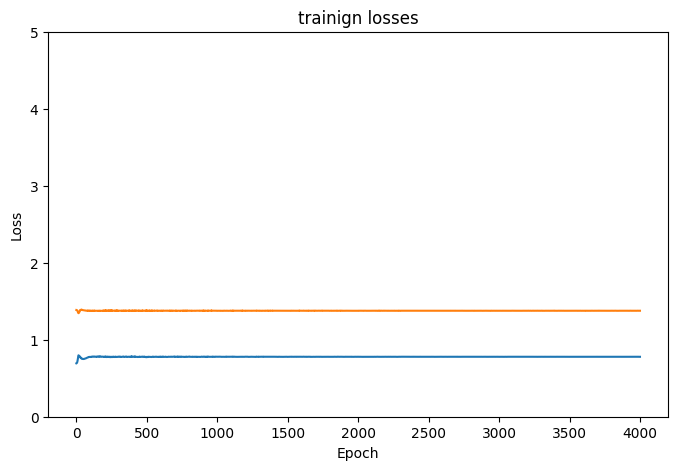

In [ ]:

#Optimizers and loss
lr = 0.0002
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# Learning rate schedulers (decay after 1000 epochs)
scheduler_G = torch.optim.lr_scheduler.StepLR(optimizer_G, step_size=1000, gamma=0.5)
scheduler_D = torch.optim.lr_scheduler.StepLR(optimizer_D, step_size=1000, gamma=0.5)

criterion = nn.BCEWithLogitsLoss()

real_label = 0.9
fake_label = 0.0

#Training loop
num_epochs = 4000
g_losses = []
d_losses = []


for epoch in range(1, num_epochs + 1):
    G.train()
    D.train()
    total_loss_D = 0
    total_loss_G = 0

    for batch in dataloader:
        real_data = batch[0].to(device)
        batch_size_curr = real_data.size(0)

        optimizer_D.zero_grad()

        labels_real = torch.full((batch_size_curr,), real_label, device=device)
        output_real = D(real_data).view(-1)
        loss_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_data = G(noise)

        labels_fake = torch.full((batch_size_curr,), fake_label, device=device)
        output_fake = D(fake_data.detach()).view(-1)
        loss_fake = criterion(output_fake, labels_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        fake_data = G(noise)

        labels_for_G = torch.full((batch_size_curr,), real_label, device=device)
        output_fake_for_G = D(fake_data).view(-1)

        loss_G = criterion(output_fake_for_G, labels_for_G)
        loss_G.backward()
        optimizer_G.step()

        total_loss_D += loss_D.item()
        total_loss_G += loss_G.item()
#Step the schedulers
    scheduler_G.step()
    scheduler_D.step()

#Record losses
    g_losses.append(total_loss_G / len(dataloader))
    d_losses.append(total_loss_D / len(dataloader))

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch [{epoch}/{num_epochs}] | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")


In [ ]:
# Generate synthetic data and saved the resulting output into a csv data
G.eval()
with torch.no_grad():
    noise = torch.randn(20000, latent_dim, device=device)
    synthetic_samples_norm = G(noise).cpu().numpy()

# Unnormalize to return to original scale
synthetic_samples = scaler.inverse_transform(synthetic_samples_norm)


synthetic_df = pd.DataFrame(synthetic_samples, columns=['Depth', 'Res', 'Su_kpa'])
synthetic_df.to_csv('synthetic_data_3.csv', index=False)

print("Synthetic data saved as 'synthetic_data_3.csv'")
print(synthetic_df.head())

Kolmogorov-Smirnov Test- statistics
# Test the fidelity of the synthetic data and original data

In [ ]:
#  import data for comaprison
df= pd.read_csv('/content/Split_train_data.csv')
Original_data = df[['Depth', 'Res', 'Su_kpa']]
old_data= Original_data


syn_data= pd.read_csv('/content/Su_Res_data.csv')
new_data=syn_data[['Depth', 'Res', 'Su_kpa']]

In [ ]:
import pandas as pd
from scipy import stats

columns_to_compare = ['Res', 'Su_kpa', 'Depth']

for col in columns_to_compare:
    # Drop missing values
    orig_values = old_data[col].dropna()
    synth_values =new_data[col].dropna()


    ks_stat, p_value = stats.ks_2samp(orig_values, synth_values)

    print(f"KS test for column '{col}':")
    print(f" KS statistic = {ks_stat:.4f}")
    print(f" p-value = {p_value:.4f}")
    print("-" * 40)

KS test for column 'Res':
  KS statistic = 0.0326
  p-value = 0.9885
----------------------------------------
KS test for column 'Su_kpa':
  KS statistic = 0.0223
  p-value = 1.0000
----------------------------------------
KS test for column 'Depth':
  KS statistic = 0.0159
  p-value = 1.0000
----------------------------------------


In [ ]:
generated_df= pd.read_csv('/content/synthetic_data_3.csv')
generated_df= generated_df[['Depth', 'Res', 'Su_kpa']]
generated_df

,Depth,Res,Su_kpa
count,301.000000,301.000000,301.000000
mean,5.868306,32.289962,539.085304
std,4.213039,19.170819,439.570474
min,0.000000,8.080000,10.725178
25%,2.090000,18.800000,184.492741
50%,5.960000,26.172000,417.199585
75%,9.150000,41.000000,797.008641
max,15.100000,109.000000,2213.912892


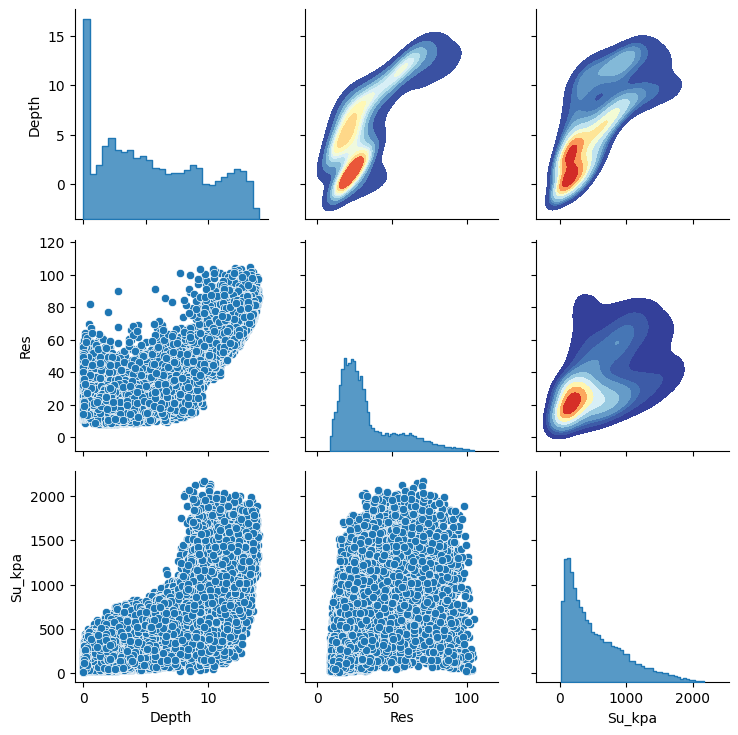

In [ ]:
# synthetic plot
syn_data = generated_df[['Depth', 'Res', 'Su_kpa']]
augment_data = pd.DataFrame(syn_data)

# Set up the PairGrid
g = sns.PairGrid(syn_data)
g.map_lower(sns.scatterplot)
g.map_upper(
    sns.kdeplot,
    cmap="RdYlBu_r",
    fill=True,
    bw_adjust=1.5,
    thresh=0.05
)
g.map_diag(sns.histplot, element="step")
plt.show()

# Define  y-axis limits
axis_limits = {
    'Depth': (0, 15),
    'Res': (0, 125),
    'Su_kpa': (0, 2500)
}

# Apply  y-axis limits
for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax:
            y_var = g.y_vars[i]
            if y_var in axis_limits:
                ax.set_ylim(axis_limits[y_var])

plt.show()
